#### 기존 seq2seq의 문제점
- 하나의 고정된 크기의 벡터에 모든 정보를 압축하다 보니 정보 손실이 발생
- RNN의 고질적인 문제인 기울기 소실문제

## 어텐션 메커니즘(Attention Mechanism)
#### 어텐션의 아이디어
- 디코더에서 출력 단어를 예측하는 매 시점마다, 인코더에서의 전체 입력 문장을 다시 한번 참고
- 전체 문장을 동일한 비율로 참고하는 것이 아닌 연관있는 단어를 집중(attention)적으로 참고

#### 어텐션 함수
- 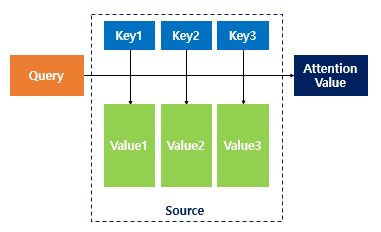

- Attention(Q, K, V) = Attention Value(Q:query, K:key, V,value)
    - 어텐션 함수는 query에 대해서 모든 key와의 유사도를 구한다.
    - 이 유사도를 key와 맵핑되어 있는 value에 반영한다.
    - 유사도가 반영된 value를 리턴한다.

```
seq2seq + 어텐션 모델
Q = Query : t 시점의 디코더 셀에서의 은닉 상태
K = Keys : 모든 시점의 인코더 셀의 은닉 상태들
V = Values : 모든 시점의 인코더 셀의 은닉 상태들
```

#### 닷-프로덕션 어텐션(Dot-Production Attention)
- 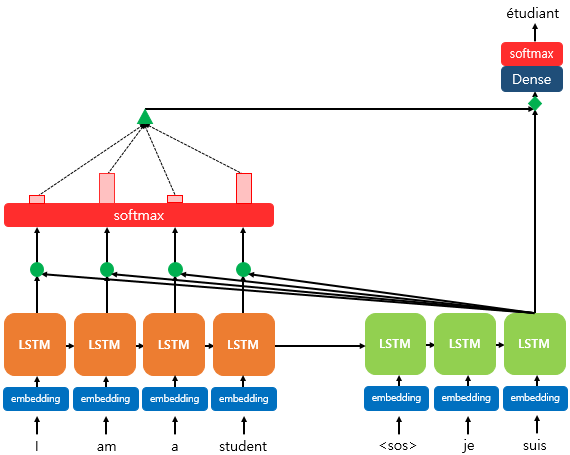

- 디코더 세번째 LSTM셀에서 출력 단어를 예측할 때, 어텐션 매커니즘을 사용
- 인코더의 소프토맥스를 통해 수치가 높은 단어의 정보를 디코더로 전송

- 기존 seq2seq의 디코더층은 이전 시점의 은닉상태와 이전 시점의 출력값을 입력으로 사용한다.
- attention 매커니즘에서는 이전 시점의 출력값을 구할 때 Attention Value라는 새로운 값이 필요하다.

- #### 1) 어텐션 스코어를 구한다.
    -  $score(s_t (= 디코더의 현재 시점의 은닉상태), h_i (= 인코더의 은닉상태)) = {s_t}^Th_i$
    - $e^t (= 인코더의 모든 은닉상태의 어텐션 스코어) = [{s_t}^T, ... , {s_t}^Th_N]$

- #### 2) 소프트맥스 함수를 통해 어텐션 분포를 구한다.
    - 어텐션 스코어 모음인 $e_t$에 소프트맥스 함수를 적용해 모든 값의 합이 1인 확률 분포를 얻는다. 이를 어텐션 가중치라고 한다.
    - $\alpha ^t = softmax(e^t)$

- #### 3) 각 인코더의 어텐션 가중치와 은닉상태를 가중합하여 어텐션 값을 구한다.
    - $a_t (= 어텐션 값) = \displaystyle\sum_{i=1}^{N}{{\alpha _i}^th_i}$
    - 어텐션값은 seq2seq에서 인코더의 마지막 은닉상태인 컨텍스트 벡터와 대조됨

- #### 4) 어텐션값과 디코더의 t 시점의 은닉상태를 연결한다.(Concatenate)
- 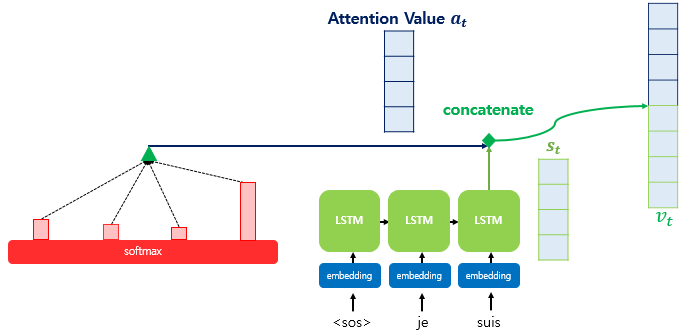

- $a_t$와 $s_t$를 결합(concatenate)하여 하나의 벡터 $v_t$로 만듬
- $v_t$는 $\hat{y}$ 예측 연산의 입력으로 사용

- #### 5) 출력층 연산의 입력이 되는 $\tilde{s}_t$를 계산합니다.
- $v_t$에 신경망 연산을 추가적으로 수행
- 이 후 하이퍼볼릭탄젠트 함수를 지남
- $\tilde{s}_t = tanh(W_c[at;st] + b_c)$

- #### 6) \tlde{s}_t$를 출력층의 입력으로 사용
- $\hat{y}_t = Softmax(W_y\tilde{s}_t + b_y)$


## 바다나우 어텐션 함수(Bahdanau Attention Function)

Attention(Q, K, V) = Attention Value
```
t = 어텐션 메커니즘이 수행되는 디코더 셀의 현재 시점을 의미
Q = Query : **t-1 시점**의 디코더 셀에서의 은닉 상태
K = Keys : 모든 시점의 인코더 셀의 은닉 상태들
V = Values : 모든 시점의 인코더 셀의 은닉 상태들
```

#### 1) 어텐션 스코어를 구한다.
- 이전 seq2seq+어텐션 메커니즘은 디코더의 t 시점의 은닉상태를 사용함
- 바다나우 어텐션은 t-1 시점의 은닉상태 $s_{t-1}$을 사용
- $score(s_{t-1}, h_i) = {W_a}^T tanh(w_bs_{t-1} + W_ch_i) \rightarrow h_i = H (h_1, h_2, h_3, h_4)$
- $e_t = {W_a}^T tanh(W_bs_{t-1} + W_CH)$

#### 2) 소프트맥스 함수를 통해 어텐션 분포를 구함
#### 3) 각 인코더의 어텐션 가중치와 은닉 상태를 가중합하여 어텐션 값을 구함
- 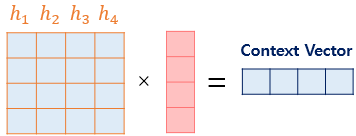

#### 4) 컨텍스트 벡터로부터 s_t를 구한다.
- 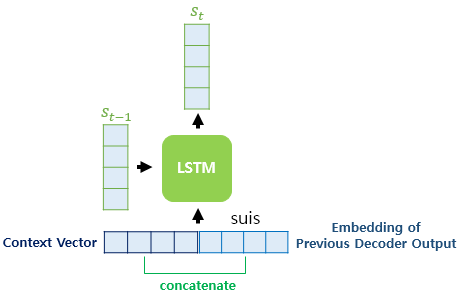
